# Quantitative Time-Series Analysis: US Sector ETFS

**Author:** Srivishnu Kotireddy
**Course:** IC Quant Mentorship - Spring 2026

## Objective
Analyze the return, volatility, and correlation structure of four major US sector ETFs relative to the broader market (SPY), and apply a forecasting model to uncover the dominant factors driving sector behavior.

## Dataset
- **Source:** Yahoo Finance (via `yfinance`)
- **Tickers:**
  - `SPY` — S&P 500 ETF (benchmark)
  - `XLK` — Technology sector
  - `XLF` — Financials sector
  - `XLE` — Energy sector
  - `XLV` — Healthcare sector
- **Fields:** Daily OHLCV, using adjusted close for return calculations
- **Data range:** 2015-01-01 to present

## Methods
1. Data collection and cleaning (missing-value audit, calendar alignment)
2. Computation of log returns and rolling statistics
3. Exploratory data analysis: cumulative returns, rolling volatility, correlation heatmap, autocorrelation diagnostics
4. Modeling: ARIMA
5. Insight synthesis and reflection

In [35]:
# Imports and Configuration #


# Core data handling 

import numpy as np
import pandas as pd

# Visualization 

import matplotlib.pyplot as plt
import seaborn as sns

# Data source 

import yfinance as yf

# Time-series statistics & modeling 

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Forecast evaluation metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Warnings (silence statsmodels convergence noise during grid search) 

import warnings
warnings.filterwarnings("ignore")


# Display and plotting config #

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context = "notebook")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


# Project constants #

TICKERS = ["SPY", "XLK", "XLF", "XLE", "XLV"]
BENCHMARK = "SPY"
START_DATE = "2015-01-01"
END_DATE = "2026-04-19"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Setup complete.")
print(f"Tickers : {TICKERS}")
print(f"Date range : {START_DATE} -> {END_DATE}")

Setup complete.
Tickers : ['SPY', 'XLK', 'XLF', 'XLE', 'XLV']
Date range : 2015-01-01 -> 2026-04-19


## 2. Data Collection

Download daily OHLCV data for our four sector ETFs plus the SPY benchmark from
Yahoo Finance via `yfinance`. I use **adjusted close** prices to account for
dividends and stock splits, which is standard for return-based analysis.

In [36]:
# Download OHLCV data from Yahoo Finance
import os

def download_prices(tickers, start, end):
    """
    Download daily adjusted close prices for a list of tickers.

    Parameters:
        - tickers : list[str]
            Ticker symbols to download(ex: ['SPY, 'XLK'])
        - start, end : str
            ISO date strings 'YYYY-MM-DD'
    
    Returns:
        - pd.DataFrame
            DataFrame indexed by date, one column per ticker, values are adjusted close prices
    """

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].rename(columns={"Close":tickers[0]})

    prices = prices[tickers]
    return prices
    

CSV_PATH = "data/sector_prices.csv"

if os.path.exists(CSV_PATH):
    prices = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
    print(f"Loaded cached prices from {CSV_PATH}")
else:
    prices = download_prices(TICKERS, START_DATE, END_DATE)
    os.makedirs("data", exist_ok=True)
    prices.to_csv(CSV_PATH)
    print(f"Downloaded from Yahoo and cached to {CSV_PATH}")


print(f"Shape            : {prices.shape}")
print(f"Date range       : {prices.index.min().date()} -> {prices.index.max().date()}")
print(f"Trading days     : {len(prices):,}")
print("\nFirst 5 rows:")
prices.head()


Loaded cached prices from data/sector_prices.csv
Shape            : (2839, 5)
Date range       : 2015-01-02 -> 2026-04-17
Trading days     : 2,839

First 5 rows:


,SPY,XLK,XLF,XLE,XLV
Date,,,,,
2015-01-02,170.1250,18.0843,16.2748,25.5481,57.0578
2015-01-05,167.0526,17.8082,15.9326,24.4912,56.7669
2015-01-06,165.4791,17.5935,15.6891,24.1314,56.5756
2015-01-07,167.5412,17.7425,15.8536,24.1828,57.9059
2015-01-08,170.5143,18.1325,16.0905,24.7257,58.8952


In [37]:
# Saving raw data to CSV

import os
os.makedirs("data", exist_ok=True)

prices.to_csv("data/sector_prices.csv")
print(f"Saved prices to data/sector_prices.csv  (shape: {prices.shape})")

Saved prices to data/sector_prices.csv  (shape: (2839, 5))


In [38]:
#Cross-check
prices.loc["2020-03-23"]

SPY   204.9449
XLK    33.5646
XLF    15.8402
XLE     9.2905
XLV    67.7696
Name: 2020-03-23 00:00:00, dtype: float64

## 3. Data Cleaning & Preprocessing

Before any analysis, verify the raw data and transform prices into **log returns**

Formula: rt = ln(Pt / P(t-1))

In [39]:
# Missing-value audit #

print("Missing values per ticker:")
print(prices.isna().sum())

print("\nDuplicated date indices:", prices.index.duplicated().sum())
print("Index is monotonic increasing:", prices.index.is_monotonic_increasing)


Missing values per ticker:
SPY    0
XLK    0
XLF    0
XLE    0
XLV    0
dtype: int64

Duplicated date indices: 0
Index is monotonic increasing: True


In [40]:
# Compute daily log returns #

def compute_log_returns(price_df):
    return np.log(price_df / price_df.shift(1)).dropna()

returns = compute_log_returns(prices)

print(f"Returns shape: {returns.shape}")
print(f"Date range   : {returns.index.min().date()} -> {returns.index.max().date()}")
print("\nFirst 5 rows of log returns:")
returns.head()

Returns shape: (2838, 5)
Date range   : 2015-01-05 -> 2026-04-17

First 5 rows of log returns:


,SPY,XLK,XLF,XLE,XLV
Date,,,,,
2015-01-05,-0.0182,-0.0154,-0.0213,-0.0422,-0.0051
2015-01-06,-0.0095,-0.0121,-0.0154,-0.0148,-0.0034
2015-01-07,0.0124,0.0084,0.0104,0.0021,0.0232
2015-01-08,0.0176,0.0217,0.0148,0.0222,0.0169
2015-01-09,-0.0080,-0.0031,-0.0136,-0.0080,-0.0089


In [41]:
# Summary statistics for reporting

summary = pd.DataFrame({
    "Mean (daily)" : returns.mean(),
    "Std Dev (daily)" : returns.std(),
    "Annualized Return" : returns.mean() * 252,
    "Annualized Vol" : returns.std() * np.sqrt(252),
    "Sharpe (rf=0)" : (returns.mean() * 252) / (returns.std() * np.sqrt(252)),
    "Min Daily Return" : returns.min(),
    "Max Daily Return" : returns.max(),
})
summary.round(4)

,Mean (daily),Std Dev (daily),Annualized Return,Annualized Vol,Sharpe (rf=0),Min Daily Return,Max Daily Return
SPY,0.0005,0.0112,0.1269,0.1775,0.7147,-0.1159,0.0999
XLK,0.0008,0.0150,0.1904,0.2376,0.8012,-0.1487,0.1260
XLF,0.0004,0.0138,0.1039,0.2189,0.4745,-0.1474,0.1236
XLE,0.0003,0.0185,0.0681,0.2942,0.2315,-0.2249,0.1487
XLV,0.0003,0.0106,0.0851,0.1678,0.5072,-0.1038,0.0742


## 4. Exploratory Data Anlaysis

Four time-series visualizations to characterize the data:
1. **Cumulative log returns** - long-run growth trajectories
2. **Rolling 30-day volatility** - how risk evolves through time
3. **Correlation heatmap** - cross-sector co-movement
4. **Autocorrelation (ACF / PACF) of SPY returns** - foundation for ARIMA order selection

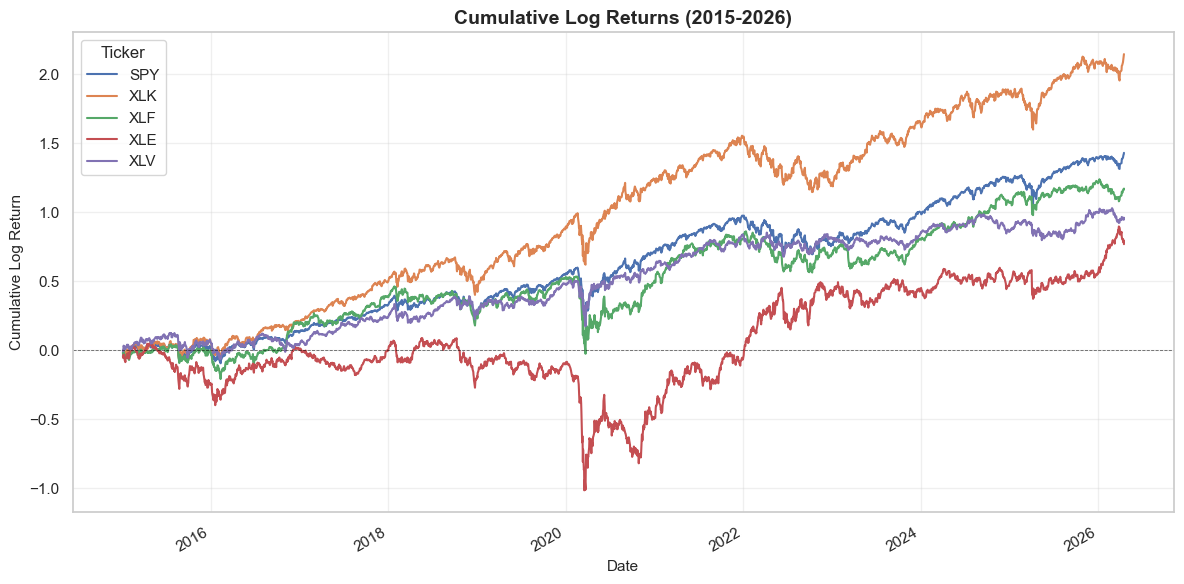

In [42]:
# 4a. Cumulative log returns - growth of $1 invested on day 1

cumulative = returns.cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
cumulative.plot(ax=ax, linewidth=1.5)

ax.set_title("Cumulative Log Returns (2015-2026)", fontsize=14, weight="bold")
ax.set_ylabel("Cumulative Log Return")
ax.set_xlabel("Date")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
ax.legend(title="Ticker", loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

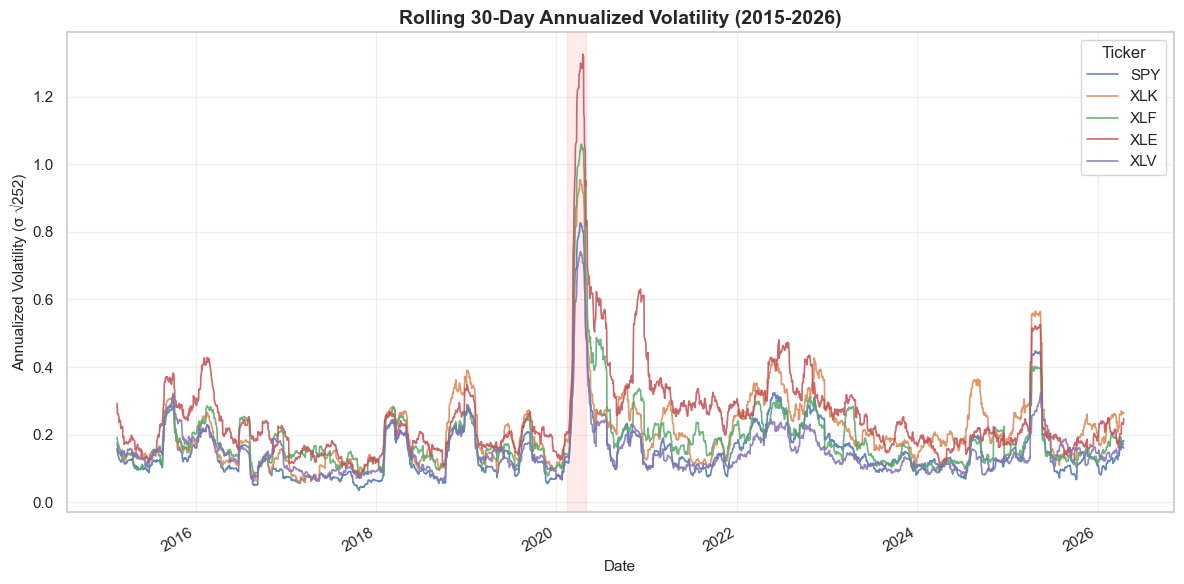

In [43]:
# 4b. Rolling 30-day annualized volatility #

WINDOW = 30

rolling_vol = returns.rolling(window=WINDOW).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6))
rolling_vol.plot(ax=ax, linewidth=1.2, alpha=0.85)

ax.set_title(f"Rolling {WINDOW}-Day Annualized Volatility (2015-2026)",
             fontsize=14, weight="bold")
ax.set_ylabel("Annualized Volatility (σ √252)")
ax.set_xlabel("Date")
ax.legend(title="Ticker", loc="upper right")
ax.grid(True, alpha=0.3)

ax.axvspan("2020-02-15", "2020-05-01",
           color="red", alpha=0.08, label="COVID crash window")

plt.tight_layout()
plt.show()

### Correlation Structure

Two correlation views: 
- The **full-sample static correlation** of daily log returns (heatmap)
- **Rolling 60day correlation** between each sector and SPY to see how these relationships evolve through time

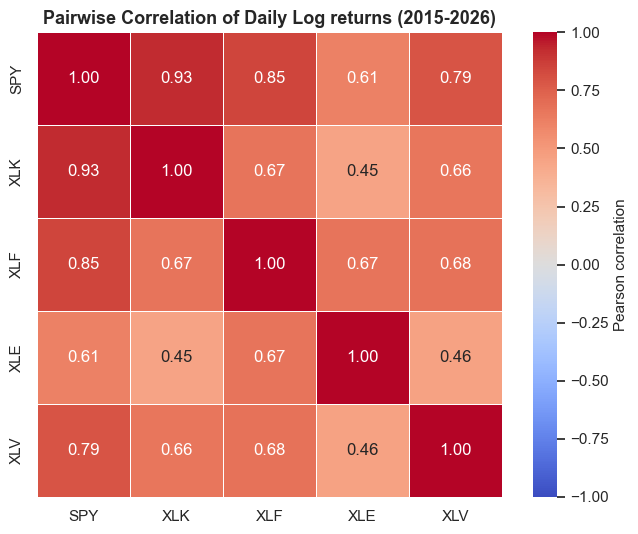

,SPY,XLK,XLF,XLE,XLV
SPY,1.0000,0.9290,0.8460,0.6120,0.7900
XLK,0.9290,1.0000,0.6710,0.4470,0.6560
XLF,0.8460,0.6710,1.0000,0.6700,0.6770
XLE,0.6120,0.4470,0.6700,1.0000,0.4570
XLV,0.7900,0.6560,0.6770,0.4570,1.0000


In [44]:
# 4c. Correlation heatmap - full-sample daily return correlations #

corr = returns.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax
)
ax.set_title("Pairwise Correlation of Daily Log returns (2015-2026)",
             fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

corr.round(3)

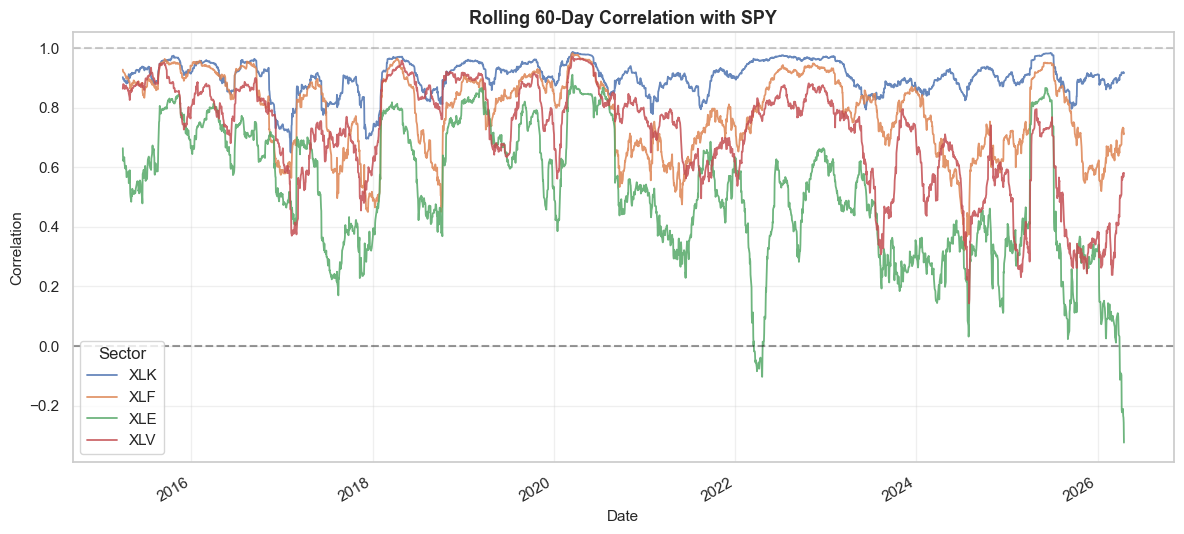

In [45]:
# 4c. Rolling 60-day correlation of each sector with SPY #

ROLL = 60
rolling_corr = pd.DataFrame({
    t:
returns[t].rolling(ROLL).corr(returns[BENCHMARK])
    for t in TICKERS if t != BENCHMARK
})

fig, ax = plt.subplots(figsize=(12, 5.5))
rolling_corr.plot(ax=ax, linewidth=1.3, alpha=0.85)

ax.set_title(f"Rolling {ROLL}-Day Correlation with SPY",
             fontsize=13, weight="bold")
ax.set_ylabel("Correlation")
ax.set_xlabel("Date")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.4)
ax.axhline(0.0, color="black", linestyle="--", alpha=0.4)
ax.legend(title="Sector", loc="lower left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Autocorrelation Structure of SPY Log Returns

Before fitting an ARIMA model, must examine the autocorrelation (ACF) and partial autocorrelation (PACF) of SPY daily log returns.

- **ACF** at lag *k* measures the correlation between today's return and the return *k* days ago --- including indirect effects through intermediate lags.
- **PACF** at lag *k* isolates the *direct* correlation after removing the influence of lags 1 through *k-1*

Run the Augmented Dickey-Fuller (ADF) test to verify stationarity.

Significant PACF spikes at the first *p* lags argue for an AR(p) component.
Significant ACF spikes at the first *q* lags argue for an MA(q) component.
A stationary series justifies `d=0` in ARIMA(p,d,q).

In [46]:
# 4d. ARIMA preq - stationarity test + ACF/PACF #

spy_returns = returns[BENCHMARK]

ad_stat,p_value, used_lag, n_obs, crit_values, _ = adfuller(spy_returns)

adf_stat, p_value, used_lag, n_obs, crit_values, _ = adfuller(spy_returns)

print("Augmented Dickey-Fuller Test on SPY log returns")
print("-" * 50)
print(f"ADF statistic : {adf_stat:.4f}")
print(f"p-value       : {p_value:.6f}")
print(f"Used lag      : {used_lag}")
print(f"Observations  : {n_obs}")
print("Critical values:")
for key, val in crit_values.items():
    print(f"   {key}: {val:.4f}")
print()

Augmented Dickey-Fuller Test on SPY log returns
--------------------------------------------------
ADF statistic : -17.1535
p-value       : 0.000000
Used lag      : 8
Observations  : 2829
Critical values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673



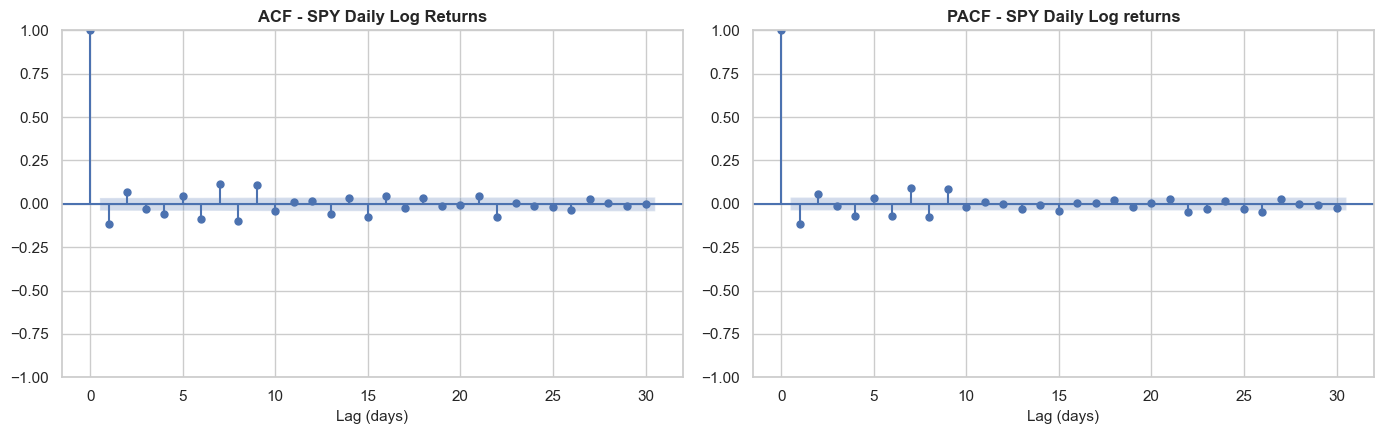

In [47]:
# ACF & PACF plots #

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(spy_returns, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF - SPY Daily Log Returns", fontsize=12, weight="bold")
axes[0].set_xlabel("Lag (days)")

plot_pacf(spy_returns, lags=30, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF - SPY Daily Log returns", fontsize=12, weight="bold")
axes[1].set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

## ARIMA Modeling of SPY Log Returns

Fit ARIMA(p, 0, q) models to SPY daily log returns across the low-roder search space suggested by the ACF/PACF diagnostics, ranking candidates by AIC and BIC and evaluating the best specification on a held-out test set.

**Train / test split:** 80% train (in-sample fit) / 20% test (out-of-sample evaluation), preserved in chronological order. No shuffling, since temporal leakage would cause the forecast metrics to be invalid.

**Evaluation metrics:** Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) vs. a naive zero-forecast baseline. Predicted zero every day baseline.

If ARIMA can't beat a flat-zero forecast, daily SPY returns contain no exploitable short-term predictability.

In [48]:
# 5a. Train / test split (chronological, no shuffling) #

spy = returns[BENCHMARK].copy()

split_idx = int(len(spy) * 0.8)
train, test = spy.iloc[:split_idx], spy.iloc[split_idx:]

print(f"Train {train.index.min().date()} -> {train.index.max().date()}"
      f"(n={len(train):,})")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()}"
      f"(n={len(test):,})")

Train 2015-01-05 -> 2024-01-10(n=2,270)
Test : 2024-01-11 -> 2026-04-17(n=568)


In [49]:
# 5b. Grid search ARIMA(p, 0 , q) over small orders #

def fit_arima_grid(series, p_values, q_values):
    """
    Fit every combination of ARIMA (p, 0, q) for the given p, q ranges and return a DataFrame ranked by AIC.
    """
    results = []
    for p in p_values:
        for q in q_values:
            try:
                model = ARIMA(series, order=(p, 0, q)).fit()
                results.append({
                    "p": p,
                    "q" : q,
                    "AIC" : model.aic,
                    "BIC": model.bic,
                    "LogLik": model.llf,
                })
            except Exception as e:
                results.append({"p": p, "q": q, "AIC": np.nan, "LogLik": np.nan})
            
    return pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)

grid = fit_arima_grid(train, p_values=[0, 1, 2], q_values=[0, 1, 2])
grid.round(2)

,p,q,AIC,BIC,LogLik
0,0,2,"-13,895.5300","-13,872.6200","6,951.7700"
1,2,0,"-13,895.2800","-13,872.3700","6,951.6400"
2,2,1,"-13,893.2400","-13,864.6000","6,951.6200"
3,1,2,"-13,891.1200","-13,862.4800","6,950.5600"
4,1,1,"-13,890.9600","-13,868.0500","6,949.4800"
5,1,0,"-13,889.8500","-13,872.6700","6,947.9200"
6,2,2,"-13,889.0200","-13,854.6500","6,950.5100"
7,0,1,"-13,885.7300","-13,868.5500","6,945.8700"
8,0,0,"-13,856.4000","-13,844.9400","6,930.2000"


In [50]:
# 5c. Fit best model on train, forecast the test horizon #

best_p = int(grid.iloc[0]["p"])
best_q = int(grid.iloc[0]["q"])
best_order = (best_p, 0, best_q)
print(f"Selected ARIMA order: {best_order}")

best_model = ARIMA(train, order=best_order).fit()
print(best_model.summary())

forecast = best_model.forecast(steps=len(test))
forecast.index = test.index

Selected ARIMA order: (0, 0, 2)
                               SARIMAX Results                                
Dep. Variable:                    SPY   No. Observations:                 2270
Model:                 ARIMA(0, 0, 2)   Log Likelihood                6951.766
Date:                Tue, 21 Apr 2026   AIC                         -13895.532
Time:                        19:10:28   BIC                         -13872.621
Sample:                             0   HQIC                        -13887.173
                               - 2270                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.793      0.073   -4.09e-05       0.001
ma.L1         -0.1159      0.009    -12.492      0.000      -0.134      -0.098
ma.L2          0.071

In [51]:
# 5d. Evaluate: ARIMA vs zero-forecast baseline #

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

naive = pd.Series(0.0, index=test.index)

metrics = pd.DataFrame({
    "RMSE": [rmse(test, forecast), rmse(test, naive)],
    "MAE": [mean_absolute_error(test, forecast), mean_absolute_error(test, naive)],
}, index=[f"ARIMA{best_order}", "Naive (zero)"])

print(metrics.round(6))

                 RMSE    MAE
ARIMA(0, 0, 2) 0.0101 0.0066
Naive (zero)   0.0102 0.0067


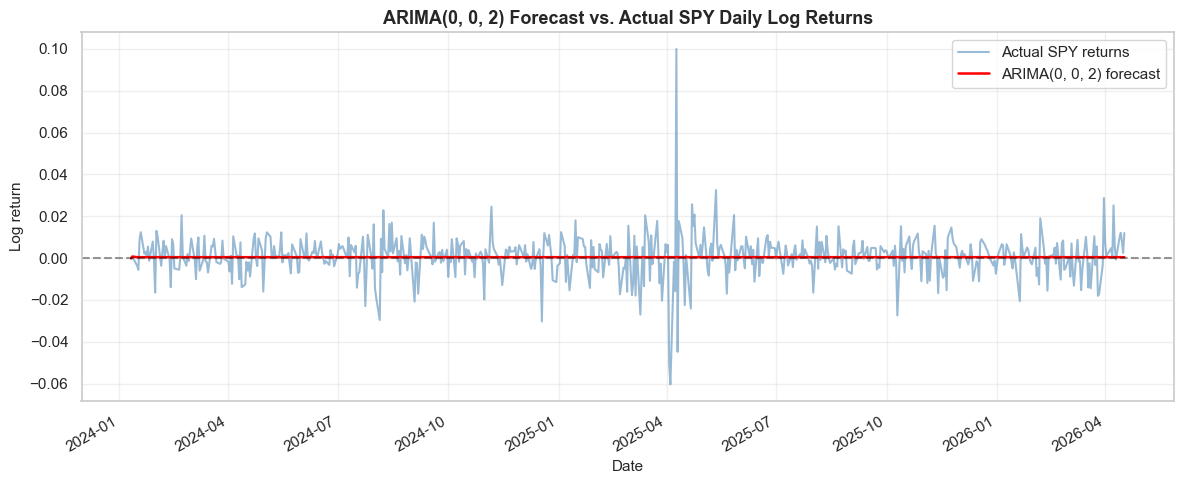

In [52]:
# 5e. Visualize forecast vs. actual #

fig, ax = plt.subplots(figsize=(12,5))
test.plot(ax=ax, alpha=0.55, label="Actual SPY returns", color="steelblue")
forecast.plot(ax=ax, color="red", linewidth=1.8, label=f"ARIMA{best_order} forecast")

ax.axhline(0, color="black", linestyle="--", alpha=0.4)
ax.set_title(f"ARIMA{best_order} Forecast vs. Actual SPY Daily Log Returns", fontsize=13, weight="bold")
ax.set_ylabel("Log return")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Insights & Discussion

Below are the main things I found from running this analysis. This pulls together what I found in the EDA and what the ARIMA model ended up showing.

### 1. SPY outperformed most of the individual sectors on a risk-adjusted basis

SPY's Sharpe of 0.71 was higher than XLF, XLE, and XLV, even though SPY is just a weighted mix of sectors. Only XLK beat it (0.80), and that came with noticeably more volatility (23.8% vs 17.8%). XLE stood out as the worst of the group: almost 30% annualized volatility for less than 7% return. The cumulative return chart shows XLE investors were underwater for roughly seven years, which surprised me, I expected energy to at least keep up with inflation over that long a window.

### 2. Sectors correlated more tightly with SPY during crises, not less

When I plotted the rolling 60-day correlation of each sector with SPY, I expected the lines to stay roughly flat. Instead, they spiked towards 0.95+ during the March 2020 crash and again during the 2022 drawdown. So the diversification benefit basically shrinks right when we'd want it most. This isn't something the static correlation heatmap captures on its own, we only see it in the rolling view.

### 3. ARIMA fit the data cleanly but barely beat the baseline

The winning model was ARIMA(0,0,2). Both MA coefficients were statistically significant, and the Ljung-Box test on residuals (p = 0.97) suggested the model captured the linear structure that was there. But the RMSE improvement over a "predict zero every day" baseline was only about 1%. So statistically the model works, but practically it's not really predicting anything useful.

The more intersting part was the residuals. Jarque-Bera rejected normaility (kurtosis around 15), and the heteroskedasticity test was significant. Basically, the variance changes over time and there are fat tails - both things ARIMA can't model. That lines up with the rolling volatility chart from earlier, where we can clearly see vol clusters during 2020 and 2022.

### 4. Takeaway on predictability

According to analysis, daily SPY returns don't really have much useful signal in their own past, at least not enough that ARIMA can pick up. This is consistent with weak-form market efficiency. If I had more time to continue this project, I'd most likely try a GARCH model next since that's built to handle the volatility clusterin that was seen, or look at whether macro indicators, like the yield curve, help predict returns where past returns alone cannot.